In [22]:
from datetime import datetime, timedelta

import h5py
import numpy as np
import pytz
import pandas as pd
import pylab as plt
from matplotlib.colors import LogNorm

import lib_dasilva2026

In [2]:

def read_dmsp_flux_file(dmsp_flux_filename):
    """Read DMSP Flux hdf or cdf file and load variables into a dictionary.
    
    Args
      dmsp_flux_filename: string path to hdf or cdf file
    Returns
      dictionary mapping parameters to file
    """
    # Open file
    hdf = h5py.File(dmsp_flux_filename, 'r')
    
    # Populate file handle dictionary 
    dmsp_flux_fh = {}    
    dmsp_flux_fh['t'] = np.array(
        [datetime(1970, 1, 1, tzinfo=pytz.utc) + timedelta(seconds=i)
         for i in hdf['Data']['Array Layout']['timestamps'][:]]
    )
    dmsp_flux_fh['ch_energy'] = hdf['Data']['Array Layout']['ch_energy'][:]
    dmsp_flux_fh['mlat'] = hdf['Data']['Array Layout']['1D Parameters']['mlat'][:]
    dmsp_flux_fh['mlong'] = hdf['Data']['Array Layout']['1D Parameters']['mlong'][:]
    dmsp_flux_fh['mlt'] = hdf['Data']['Array Layout']['1D Parameters']['mlt'][:]
    dmsp_flux_fh['el_d_ener'] = hdf['Data']['Array Layout']['2D Parameters']['el_d_ener'][:]
    dmsp_flux_fh['ion_d_ener'] = hdf['Data']['Array Layout']['2D Parameters']['ion_d_ener'][:]
                
    return dmsp_flux_fh

In [10]:
dmsp_data = read_dmsp_flux_file('data/dms_20151221_16e.001.hdf5')

In [38]:
tracers_data = data = lib_dasilva2026.load_data(
    aci_file='data/ts2_l2_aci_ipd_20251116_v0.8.0.cdf',
    ead_file='data/ts2_def_ead_20251116_v0.10.0.cdf',
)

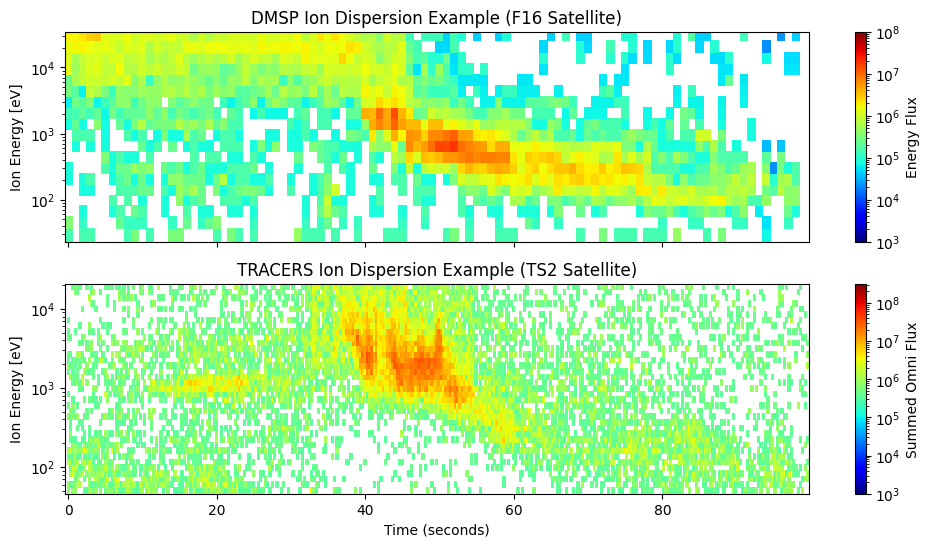

In [64]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot DMSP Data
dmsp_stime = datetime(2015, 12, 21, 4, 9, 50, tzinfo=pytz.utc)
dmsp_etime = dmsp_stime + timedelta(seconds=100)

mask = (dmsp_data['t'] > dmsp_stime)  & (dmsp_data['t'] < dmsp_etime)


t = dmsp_data['t'][mask] - dmsp_data['t'][mask][0]
t = [_.total_seconds() for _ in t]

im = axes[0].pcolor(t, dmsp_data['ch_energy'], dmsp_data['ion_d_ener'][:, mask],
              norm=LogNorm(vmin=1e3, vmax=1e8), cmap='jet')
axes[0].set_yscale('log')
axes[0].set_ylabel('Ion Energy [eV]')
plt.colorbar(im, ax=axes[0]).set_label('Energy Flux')
axes[0].set_title('DMSP Ion Dispersion Example (F16 Satellite)')

tracers_stime = datetime(2025, 11, 16, 21, 50, 30)
tracers_etime = datetime(2025, 11, 16, 21, 52, 10)
mask = (tracers_data.time > tracers_stime) & (tracers_data.time < tracers_etime)

t = tracers_data.time[mask] - tracers_data.time[mask][0]
t = [_.total_seconds() for _ in t]


im = axes[1].pcolor(t, tracers_data.energies[10:], tracers_data.spect[mask, 10:].T,
              norm=LogNorm(vmin=1e3, vmax=10**(8.5)), cmap='jet')
axes[1].set_yscale('log')
axes[1].set_ylabel('Ion Energy [eV]')
axes[1].set_title('TRACERS Ion Dispersion Example (TS2 Satellite)')
plt.colorbar(im, ax=axes[1]).set_label('Summed Omni Flux')

axes[1].set_xlabel('Time (seconds)')

fig.savefig('plots/dmsp_vs_tracers.png', dpi=300, bbox_inches='tight')